# Nama: Herri Subroto Nainggolan
# NIM: 4222301075
# Kelas: C PAGI


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


## Load Our Dataset


In [4]:
df = pd.read_csv('WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA


Text(0.5, 1.0, 'Sebaran Nilai Alcohol vs pH')

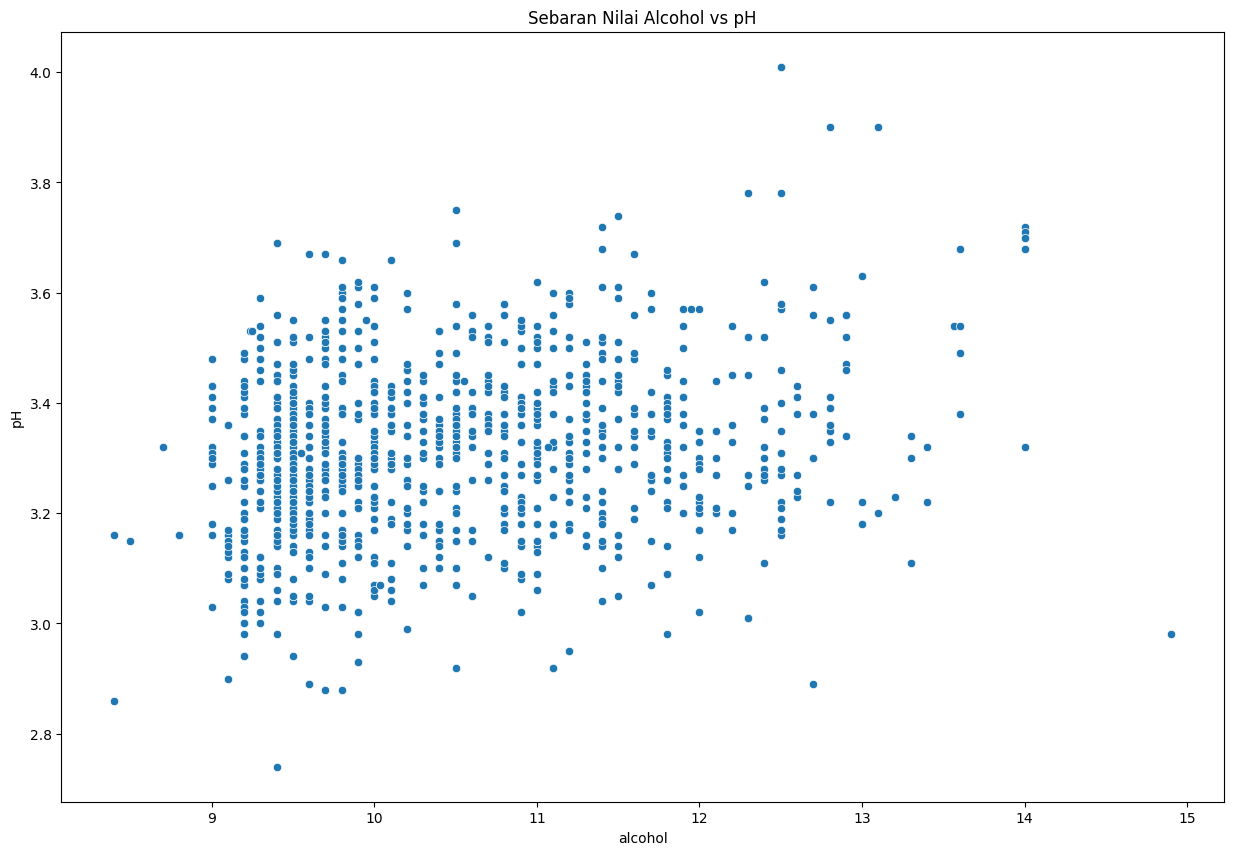

In [5]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH')
plt.title('Sebaran Nilai Alcohol vs pH')


In [6]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


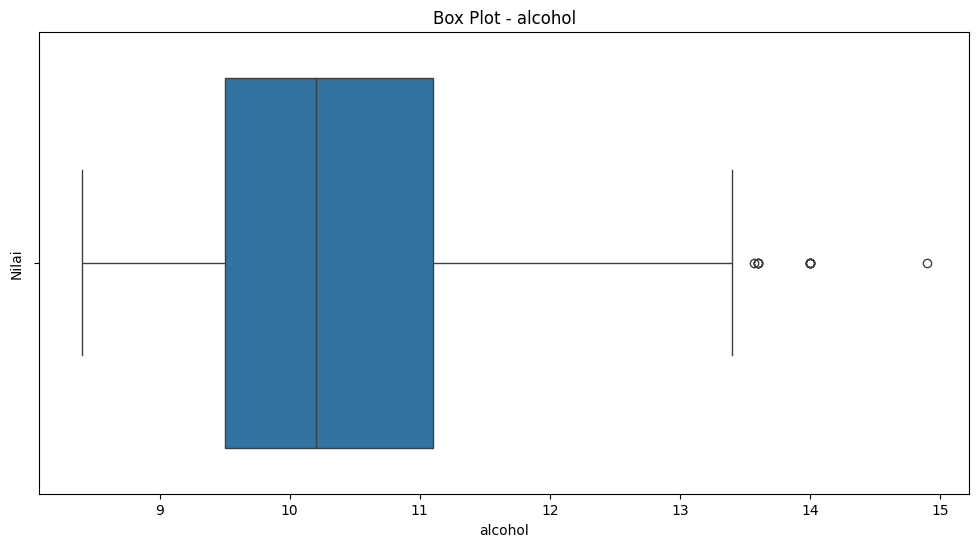

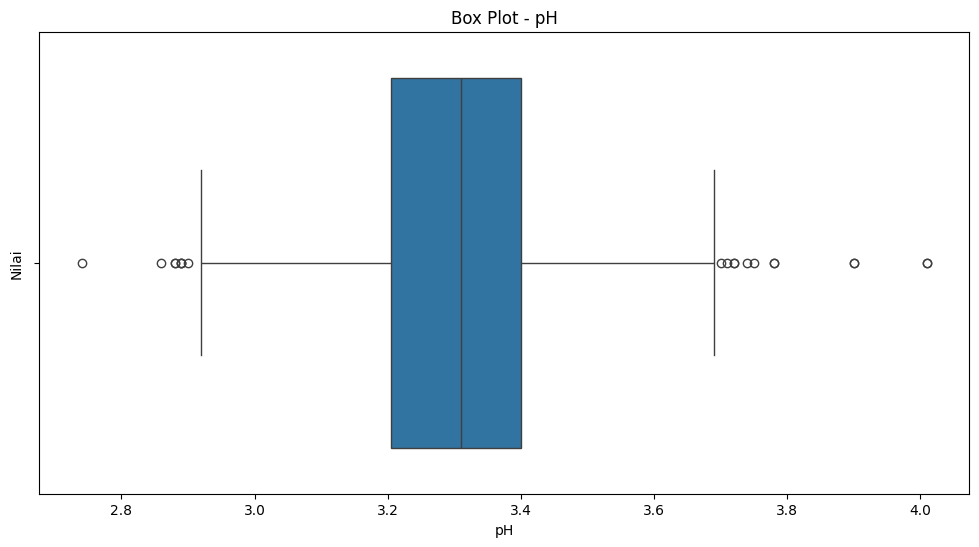

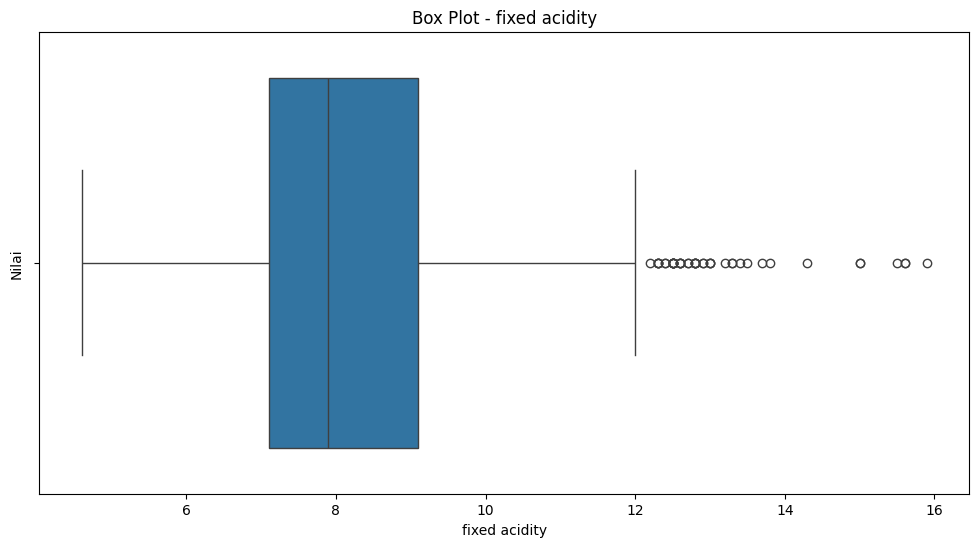

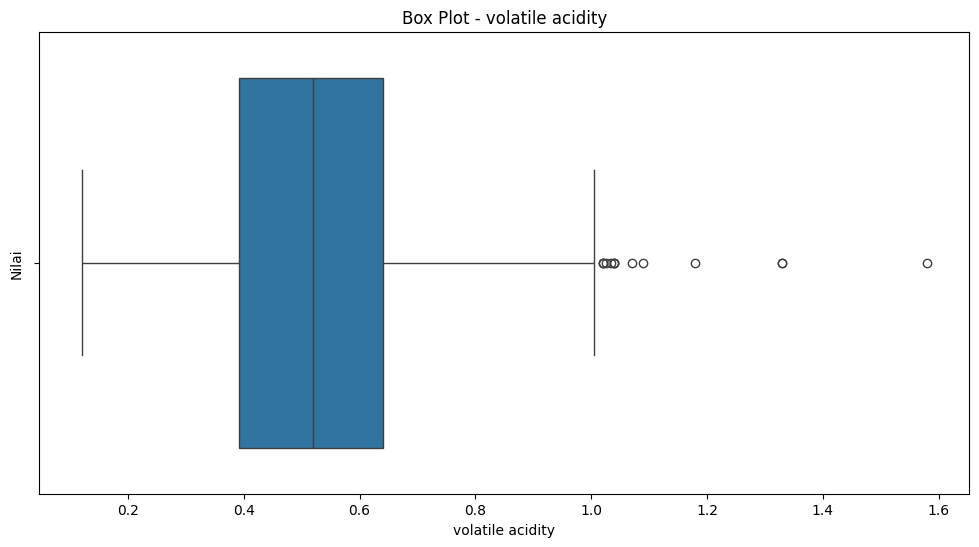

In [7]:
# Looping untuk beberapa fitur penting
columns = ['alcohol', 'pH', 'fixed acidity', 'volatile acidity']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()


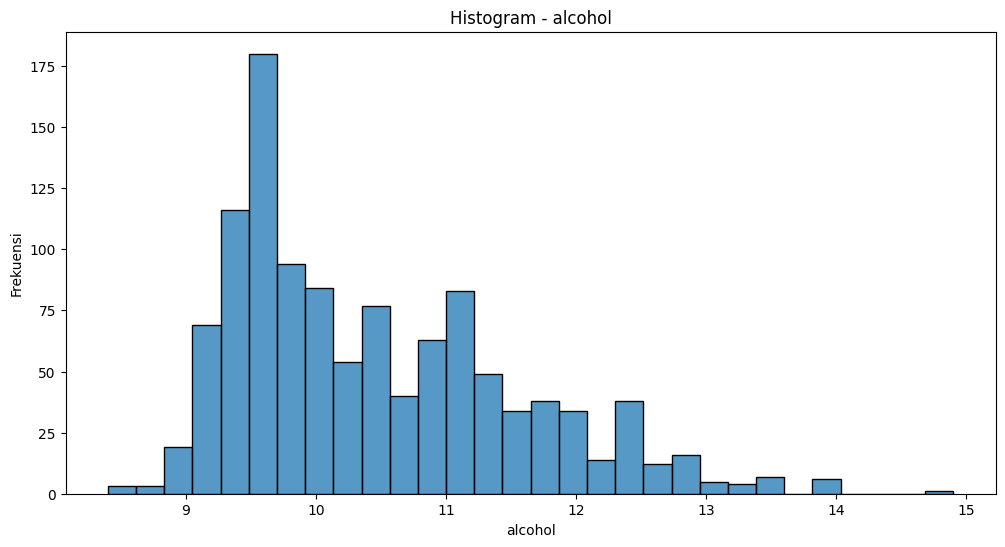

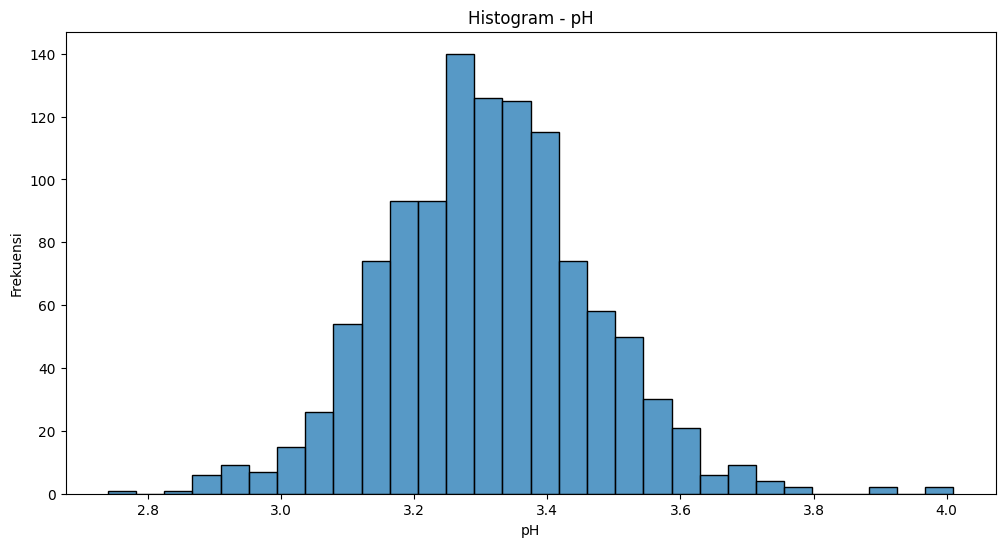

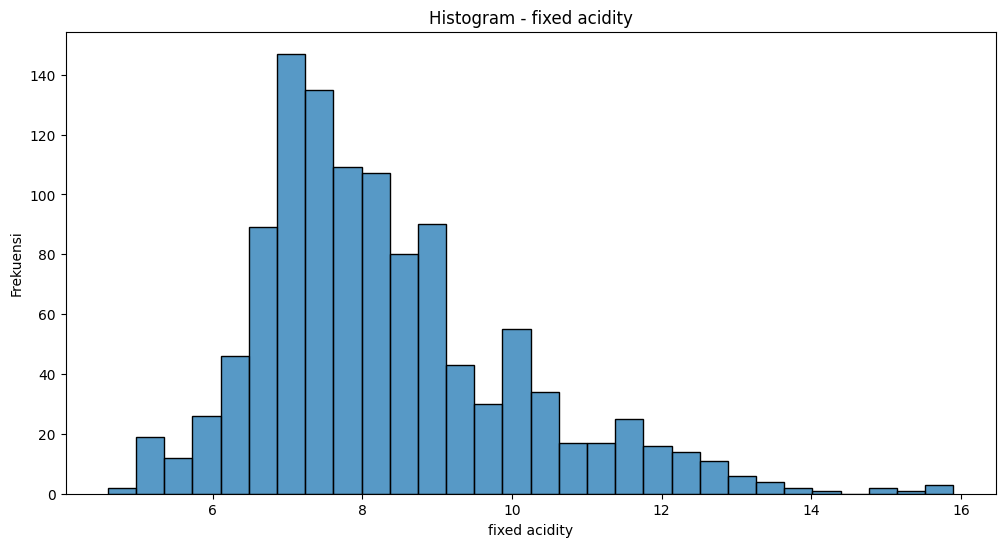

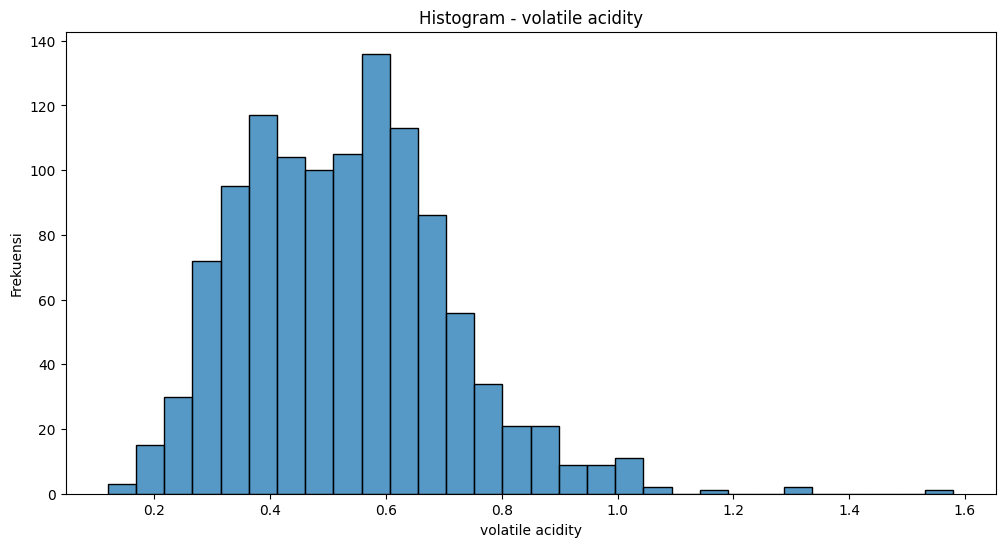

In [8]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()


## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu
3. Feature Scalling


In [9]:
# Drop Duplicates
print(f"Dataframe dimension before duplication drop {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataframe dimension after duplication drop {df.shape[0]}")


Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


In [10]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
X = df[fitur_columns].values
y = df['quality'].values #anotator label


In [11]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [12]:
X_std


array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]], shape=(1143, 11))

In [13]:
df_scalling


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


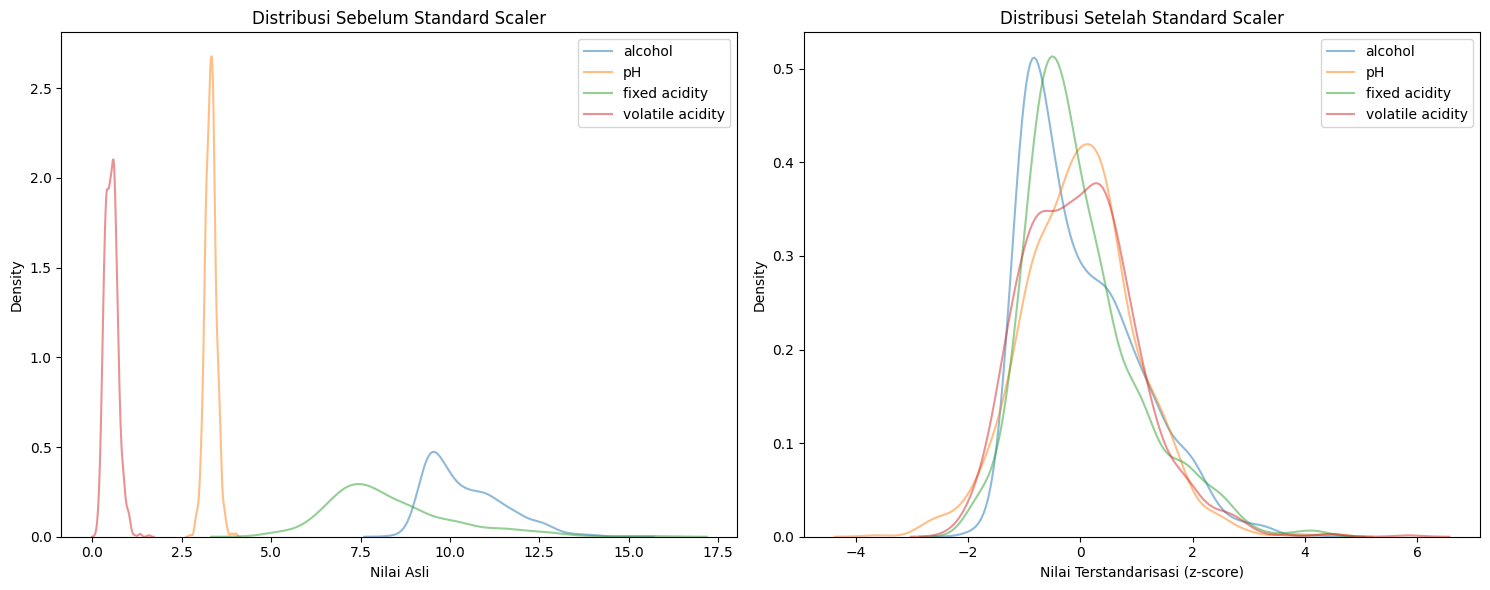

In [14]:
#cek grafik sebelum dan setelah scalling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 6))

# Plot distribusi sebelum Standar Scaler
for col in ['alcohol', 'pH', 'fixed acidity', 'volatile acidity']:
    sns.kdeplot(df[col], ax=ax1, label=col, alpha=0.5)
ax1.set_title('Distribusi Sebelum Standard Scaler')

# Plot distribusi setelah Standar Scaler
for col in ['alcohol', 'pH', 'fixed acidity', 'volatile acidity']:
    sns.kdeplot(df_scalling[col], ax=ax2, label=col, alpha=0.5)
ax2.set_title('Distribusi Setelah Standard Scaler')

ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Terstandarisasi (z-score)')

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot


### Metode Elbow


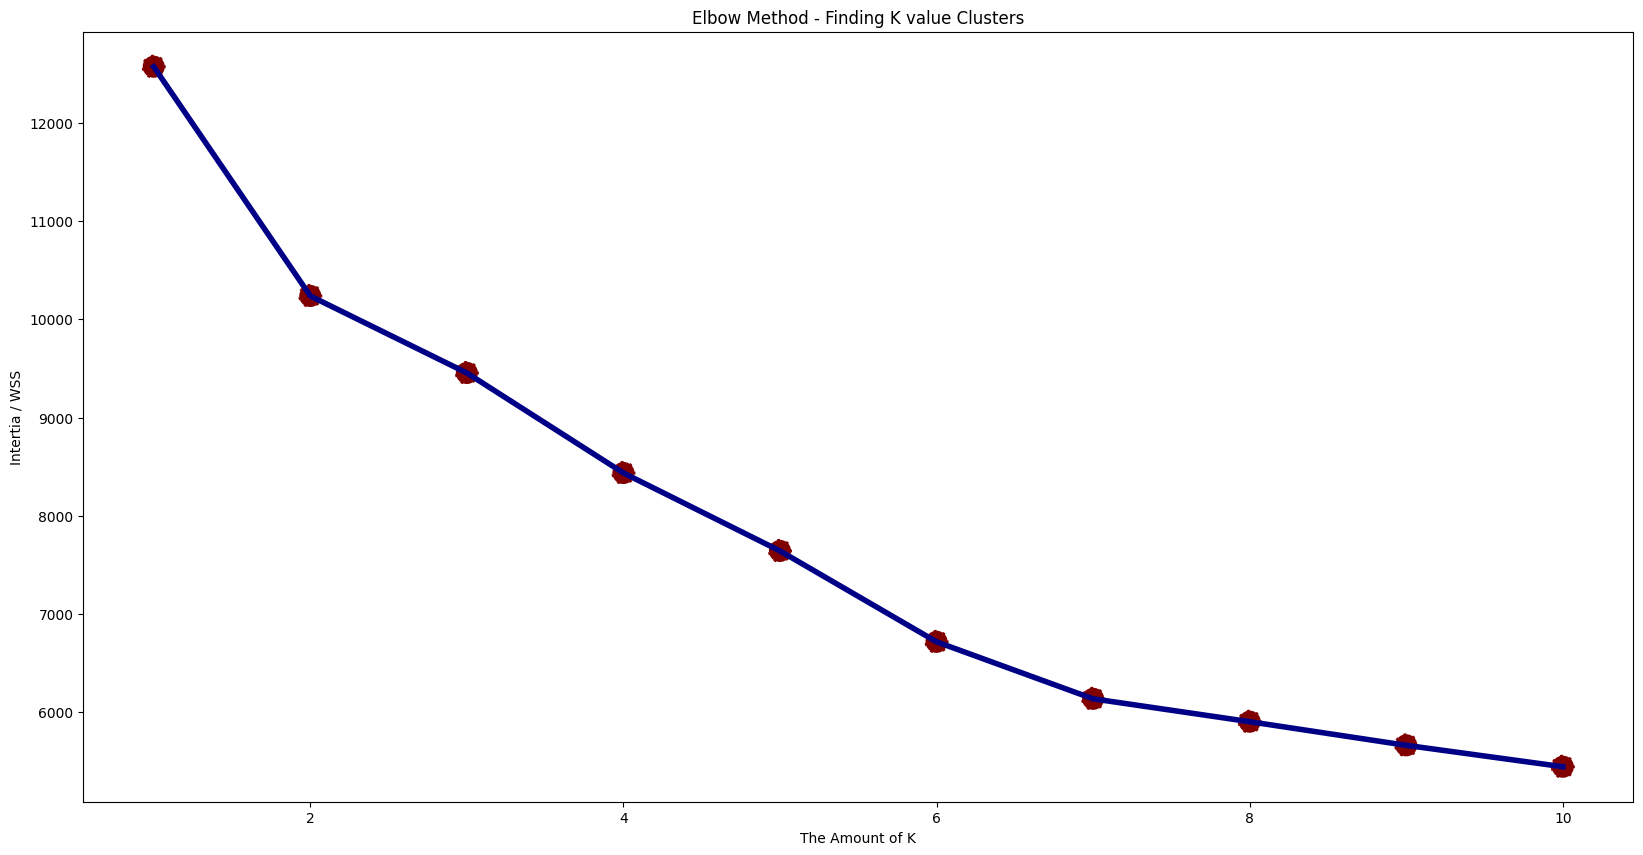

In [15]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')
plt.show()


In [16]:
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=6, random_state=0)
kmeans_elbow.fit(df_scalling.values)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [17]:
df['cluster_elbow'] = kmeans_elbow.labels_


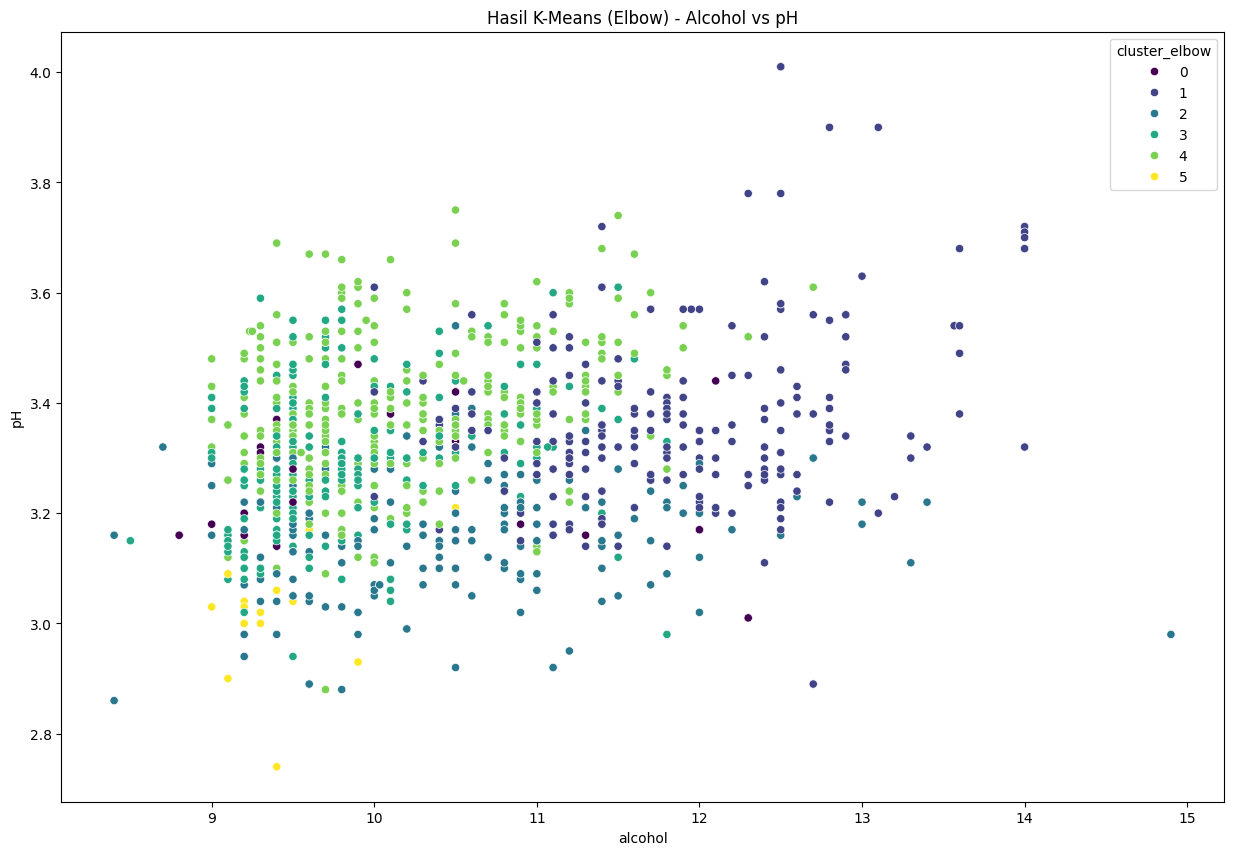

In [18]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='cluster_elbow', palette='viridis')
plt.title('Hasil K-Means (Elbow) - Alcohol vs pH')
plt.show()


### Bandingkan hasil dengan label anotator


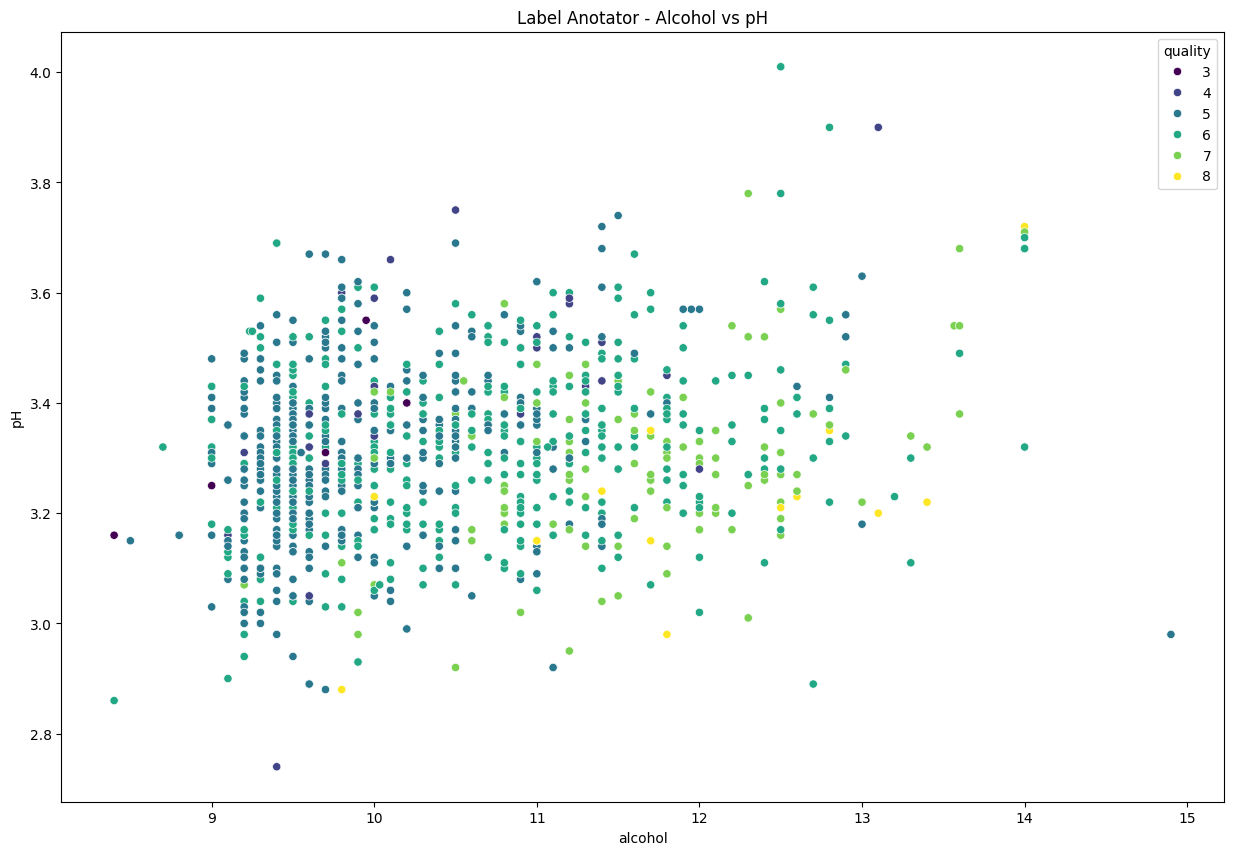

In [19]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='quality', palette='viridis')
plt.title('Label Anotator - Alcohol vs pH')
plt.show()


### 2. Via Score Plot


In [20]:
!pip install yellowbrick


Defaulting to user installation because normal site-packages is not writeable


In [21]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans(random_state=0)
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
visualizer.show()


ModuleNotFoundError: No module named 'distutils'

In [ ]:
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=5, random_state=0)
kmeans_via.fit(df_scalling.values)


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [ ]:
df['cluster_via'] = kmeans_via.labels_


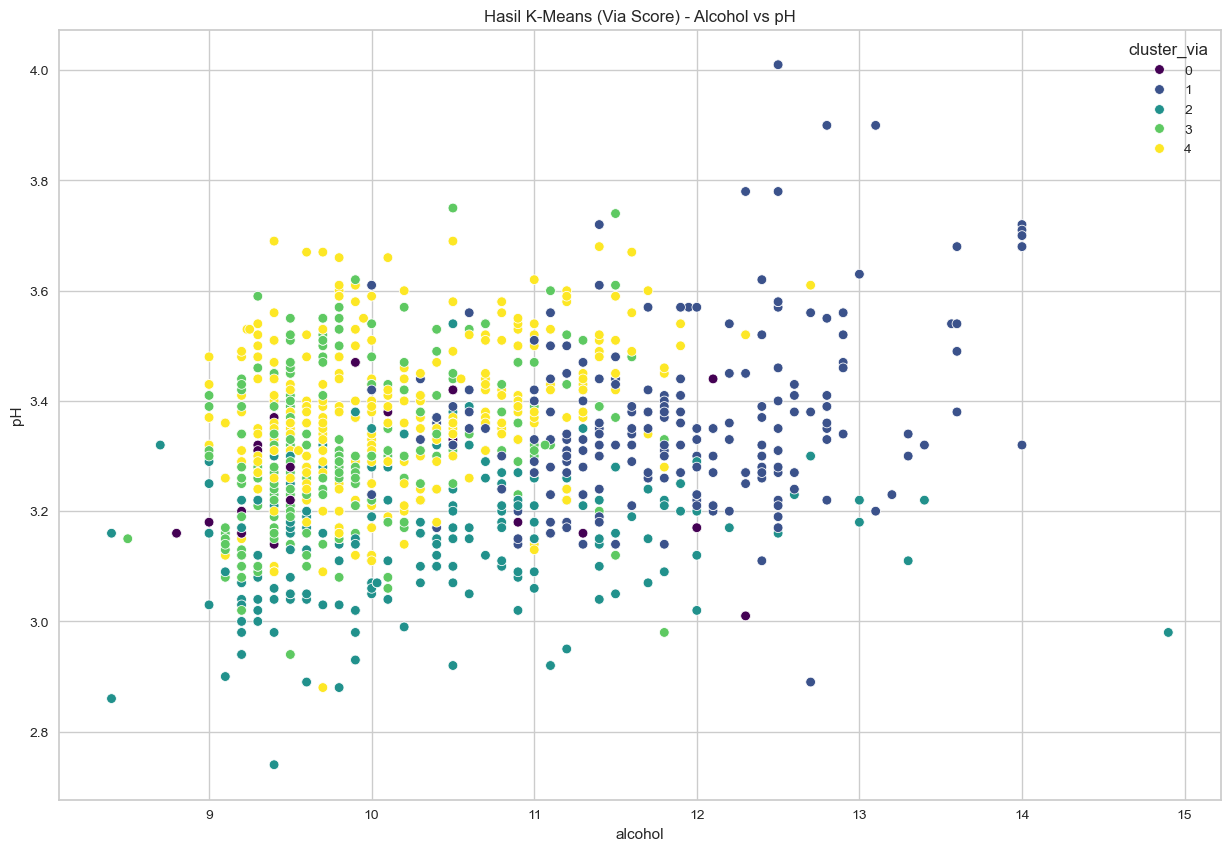

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='cluster_via', palette='viridis', ax=ax)
plt.title('Hasil K-Means (Via Score) - Alcohol vs pH')
plt.show()


### Bandingkan dengan label anotator


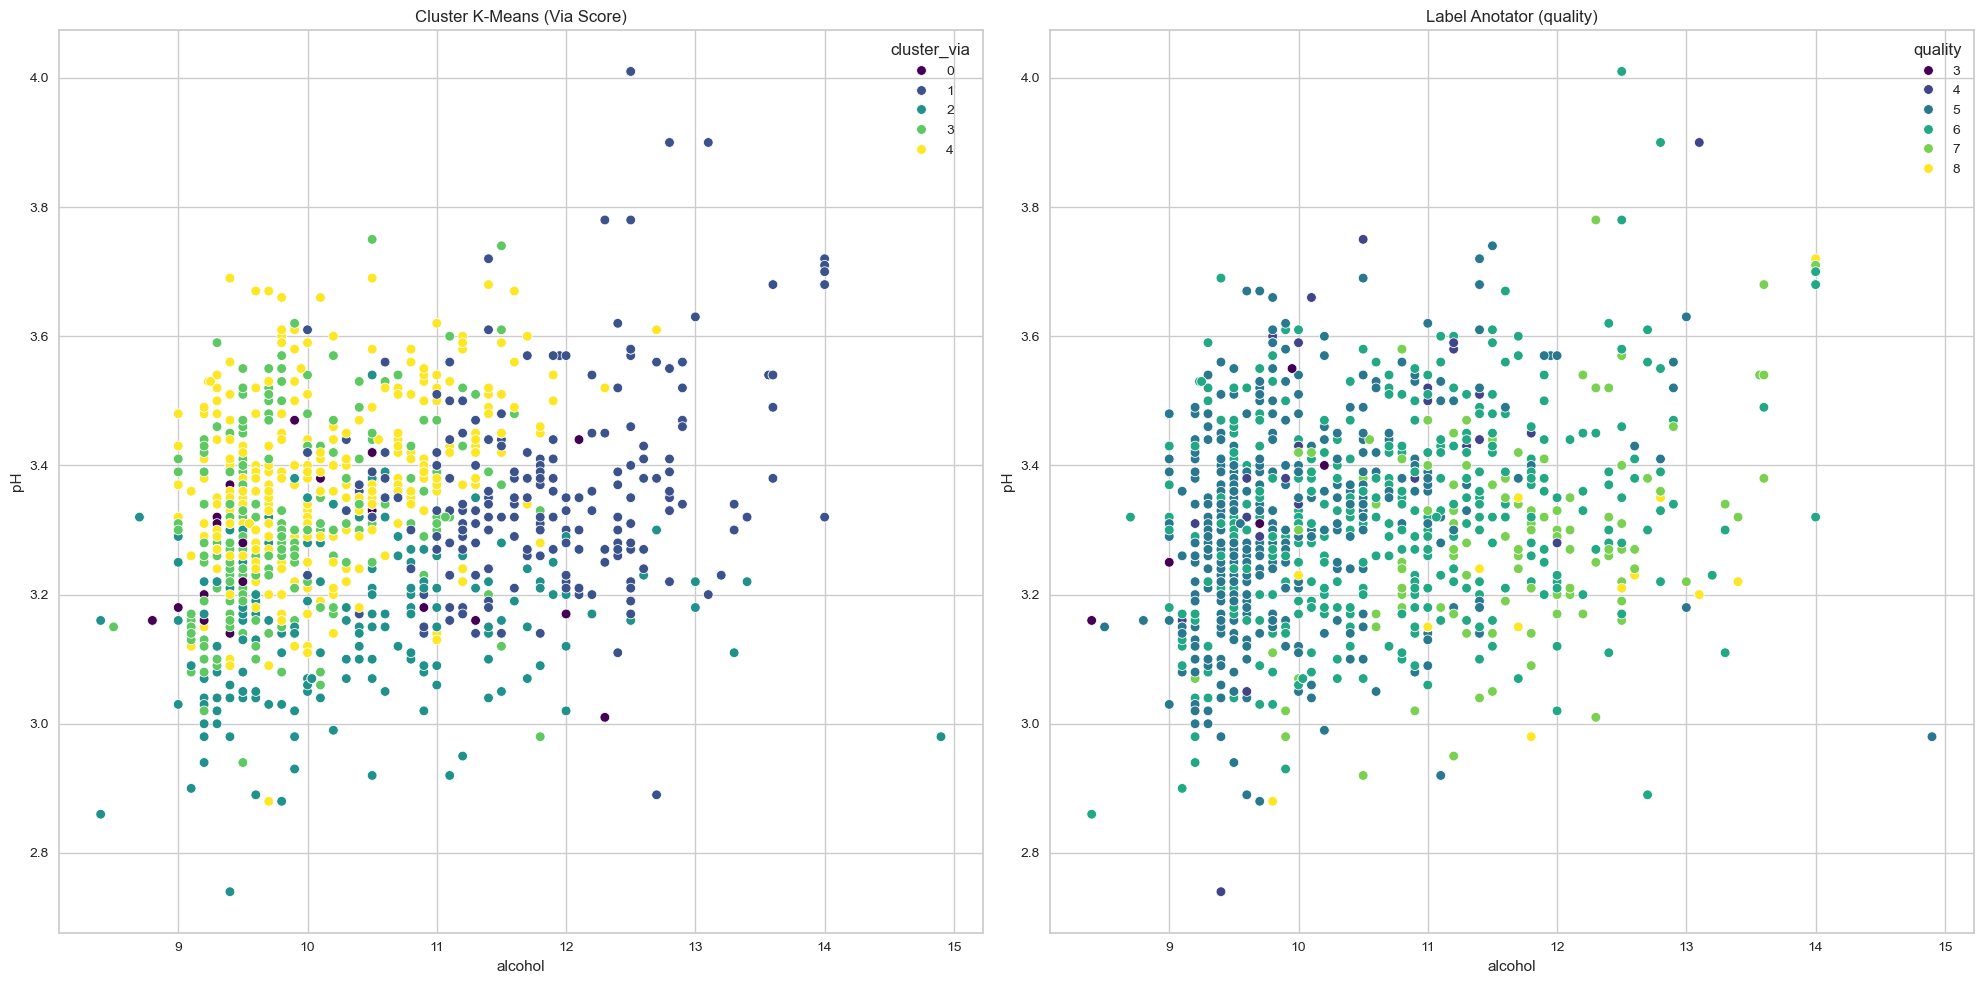

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='cluster_via', palette='viridis', ax=ax1)
ax1.set_title('Cluster K-Means (Via Score)')
sns.scatterplot(data=df, x='alcohol', y='pH', hue='quality', palette='viridis', ax=ax2)
ax2.set_title('Label Anotator (quality)')
plt.tight_layout()
plt.show()
